In [23]:
import typing
import pickle
import os
import pathlib
import pathlib

import fetch_prs
import pr_classes

SCRIPT_PATH = pathlib.Path(os.path.abspath('/home/user/university/masters_second_semester_software_engineering_methodology/lab1/main.ipynb'))
SCRIPT_DIR = SCRIPT_PATH.parent
BUILD_DIR = SCRIPT_DIR / 'build'

with open(BUILD_DIR / 'ser_prs.pickle', 'rb') as fileio:
    ser_prs = typing.cast(pr_classes.PrBlob, pickle.load(fileio))

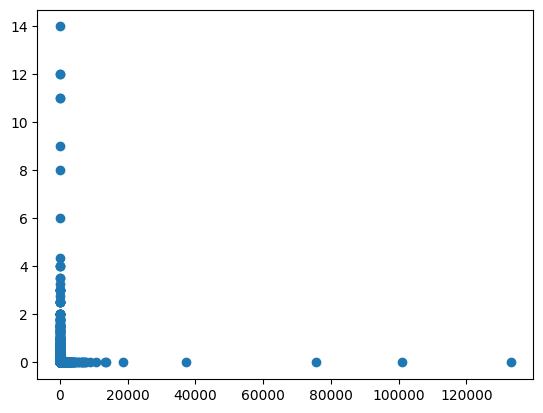

In [24]:
import numpy as np
import matplotlib.pyplot as plt

size_list: list[int] = []
density_list: list[float] = []

for pr in ser_prs.prs:
    size = pr.additions + pr.deletions
    if size == 0:
        continue
    density = len(pr.comments) / size
    size_list.append(size)
    density_list.append(density)

plt.scatter(size_list, density_list)

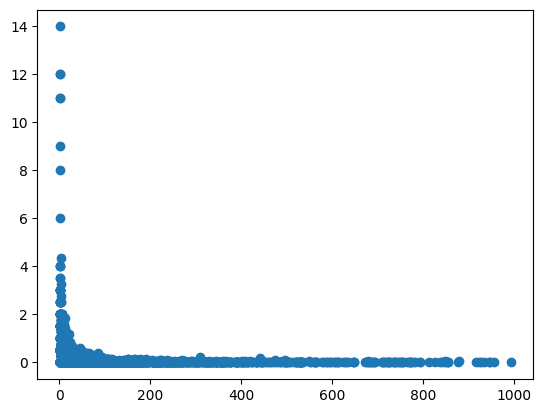

np.float64(-0.15109664884922144)

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

size_list: list[int] = []
density_list: list[float] = []

for pr in ser_prs.prs:
    size = pr.additions + pr.deletions
    if size == 0 or size > 1000:
        continue
    density = len(pr.comments) / size
    size_list.append(size)
    density_list.append(density)

plt.scatter(size_list, density_list)
plt.show()

corr_size_density, p_value1 = scipy.stats.pearsonr(size_list, density_list)
corr_size_density

Кореляція (Size vs Density): -0.1511 (p-value: 4.7187e-15)
Кореляція (Files vs Comments): 0.0419 (p-value: 2.6730e-02)


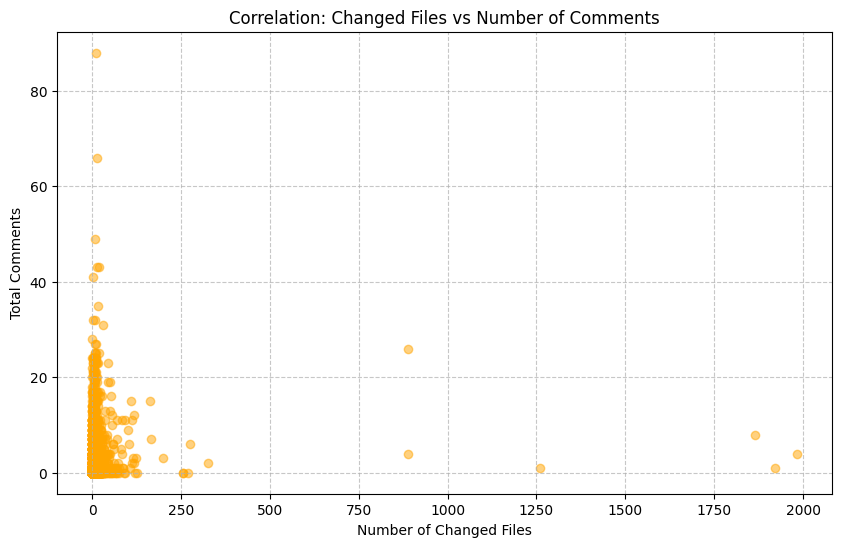

In [26]:
files_list = tuple(pr.changedFiles for pr in ser_prs.prs)
comments_count_list = tuple(len(pr.comments) for pr in ser_prs.prs)

corr_files_comments, p_value2 = scipy.stats.pearsonr(files_list, comments_count_list)

print(f"Кореляція (Size vs Density): {corr_size_density:.4f} (p-value: {p_value1:.4e})")
print(f"Кореляція (Files vs Comments): {corr_files_comments:.4f} (p-value: {p_value2:.4e})")

plt.figure(figsize=(10, 6))
plt.scatter(files_list, comments_count_list, alpha=0.5, color='orange')
plt.title('Correlation: Changed Files vs Number of Comments')
plt.xlabel('Number of Changed Files')
plt.ylabel('Total Comments')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Кореляція (Size vs Density): -0.1511 (p-value: 4.7187e-15)
Кореляція (Files vs Comments): 0.1053 (p-value: 2.7338e-08)


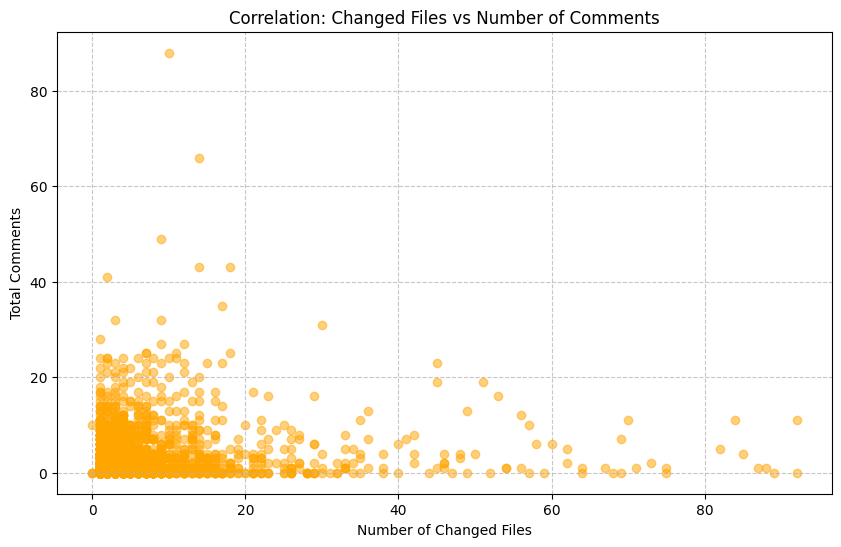

In [27]:
files_list: list[int] = []
comments_count_list: list[int] = []

for pr in ser_prs.prs:
    if pr.changedFiles < 100:
        files_list.append(pr.changedFiles)
        comments_count_list.append(len(pr.comments))

corr_files_comments, p_value2 = scipy.stats.pearsonr(files_list, comments_count_list)

print(f"Кореляція (Size vs Density): {corr_size_density:.4f} (p-value: {p_value1:.4e})")
print(f"Кореляція (Files vs Comments): {corr_files_comments:.4f} (p-value: {p_value2:.4e})")

plt.figure(figsize=(10, 6))
plt.scatter(files_list, comments_count_list, alpha=0.5, color='orange')
plt.title('Correlation: Changed Files vs Number of Comments')
plt.xlabel('Number of Changed Files')
plt.ylabel('Total Comments')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

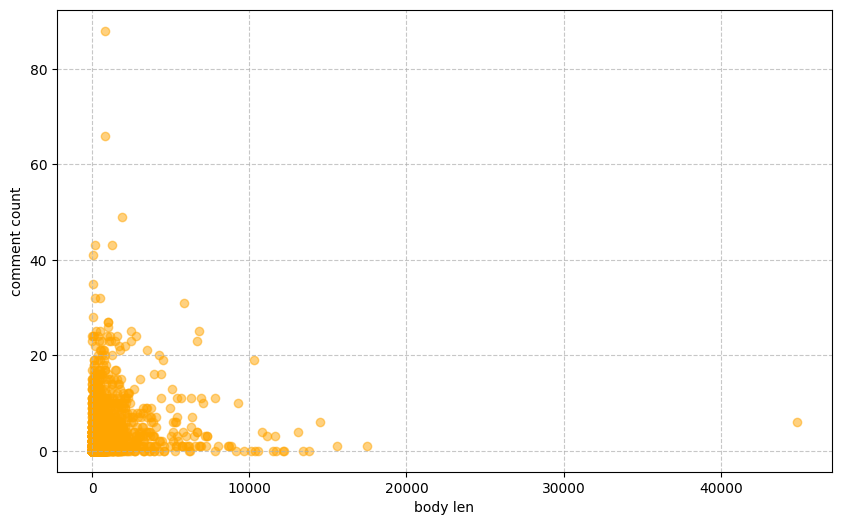

In [28]:
pr_body_lens: list[int] = []
pr_comments_counts: list[int] = []
for pr in ser_prs.prs:
    pr_body_lens.append(len(pr.body))
    pr_comments_counts.append(len(pr.comments))

plt.figure(figsize=(10, 6))
plt.scatter(pr_body_lens, pr_comments_counts, alpha=0.5, color='orange')
plt.xlabel('body len')
plt.ylabel('comment count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

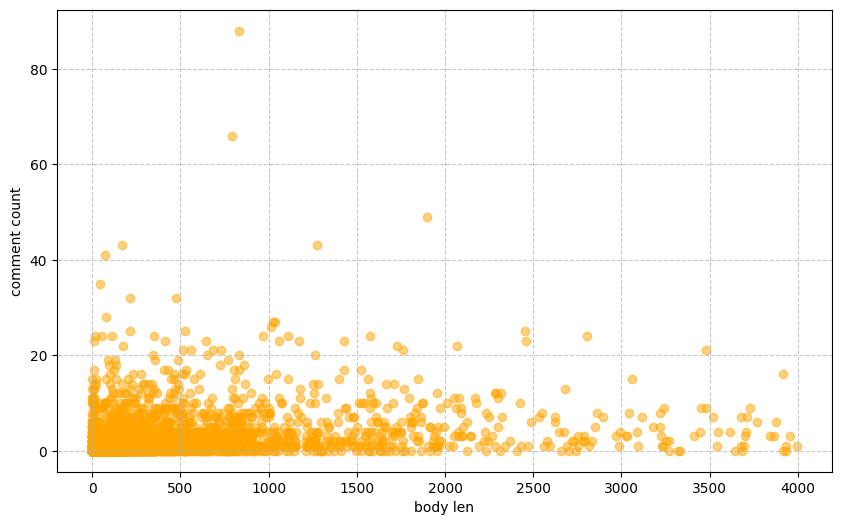

In [29]:
pr_body_lens: list[int] = []
pr_comments_counts: list[int] = []
for pr in ser_prs.prs:
    body_len = len(pr.body)
    if body_len < 4000:
        pr_body_lens.append(body_len)
        pr_comments_counts.append(len(pr.comments))

plt.figure(figsize=(10, 6))
plt.scatter(pr_body_lens, pr_comments_counts, alpha=0.5, color='orange')
plt.xlabel('body len')
plt.ylabel('comment count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

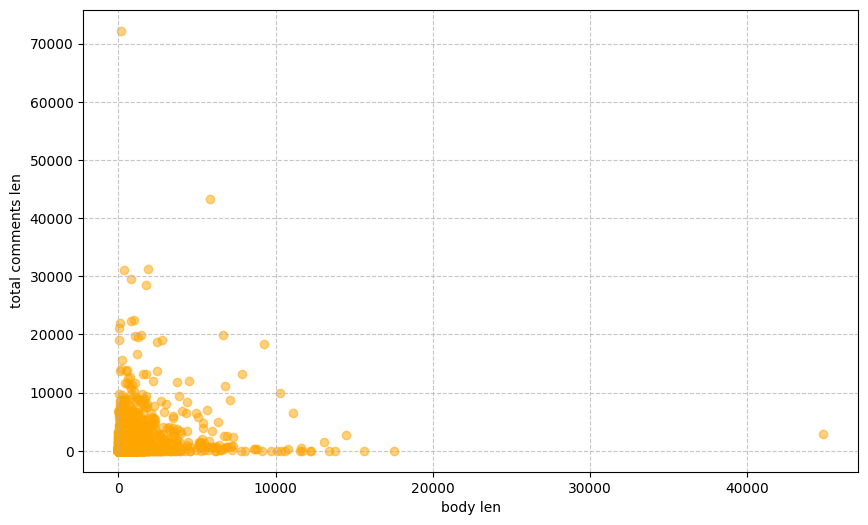

In [30]:
pr_body_lens: list[int] = []
pr_comments_counts: list[int] = []
for pr in ser_prs.prs:
    pr_body_lens.append(len(pr.body))
    pr_comments_counts.append(sum(len(comment.body) for comment in pr.comments))

plt.figure(figsize=(10, 6))
plt.scatter(pr_body_lens, pr_comments_counts, alpha=0.5, color='orange')
plt.xlabel('body len')
plt.ylabel('total comments len')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

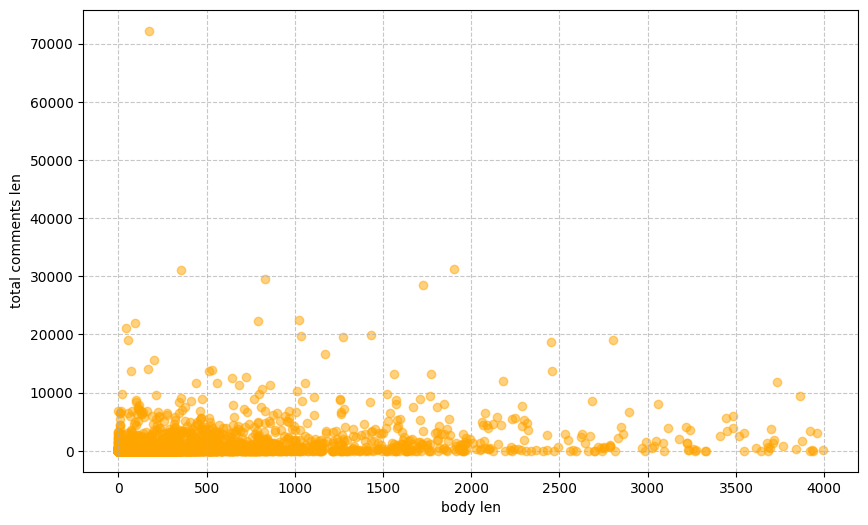

In [31]:
pr_body_lens: list[int] = []
pr_comments_counts: list[int] = []

for pr in ser_prs.prs:
    body_len = len(pr.body)
    if body_len < 4000:
        pr_body_lens.append(body_len)
        pr_comments_counts.append(sum(len(comment.body) for comment in pr.comments))

plt.figure(figsize=(10, 6))
plt.scatter(pr_body_lens, pr_comments_counts, alpha=0.5, color='orange')
plt.xlabel('body len')
plt.ylabel('total comments len')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

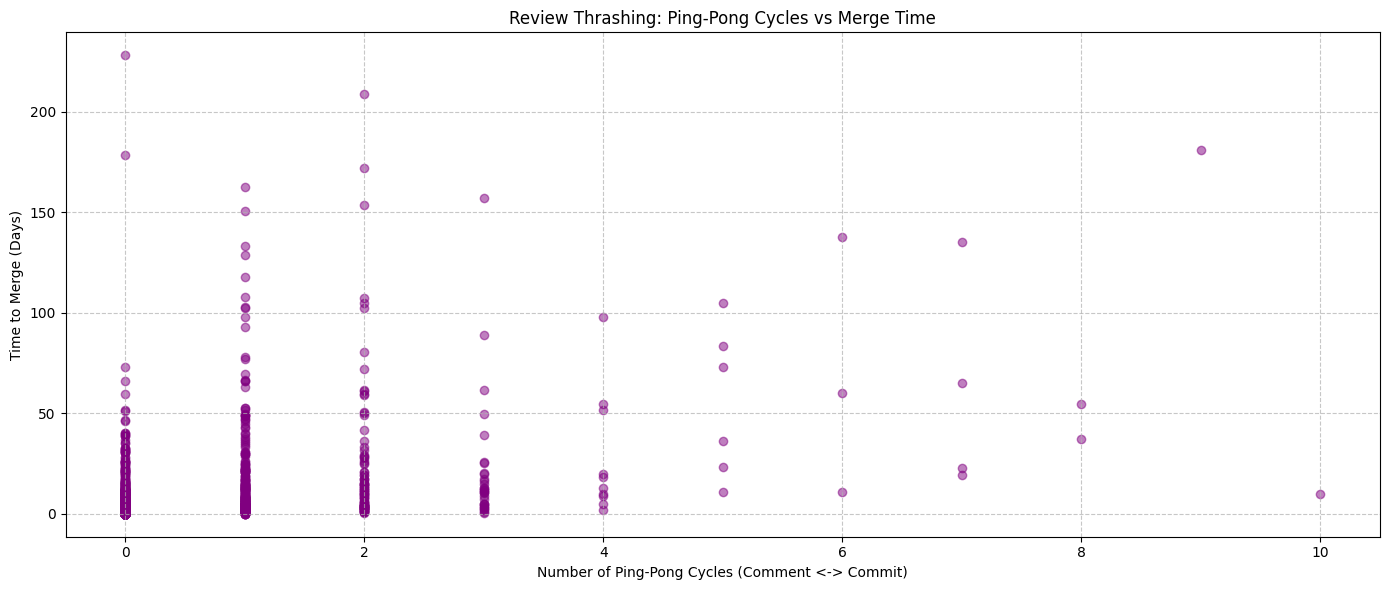

In [39]:
import datetime
import matplotlib.pyplot as plt

class CommitEvent(typing.NamedTuple):
    dt: datetime.datetime

class CommentEvent(typing.NamedTuple):
    dt: datetime.datetime

type PrEvent = CommitEvent | CommentEvent

ping_pong_counts: list[int] = []
merge_times_days: list[float] = []

for pr in ser_prs.prs:
    if pr.mergedAt is None:
        continue

    events: list[PrEvent] = []
    for c in pr.commits:
        events.append(CommitEvent(datetime.datetime.fromisoformat(c.committedDate.replace('Z', '+00:00'))))
    for c in pr.comments:
        if c.author.login != pr.author.login:
            events.append(CommentEvent(datetime.datetime.fromisoformat(c.createdAt.replace('Z', '+00:00'))))
    events.sort(key=lambda x: x.dt)
    
    first_comment_idx = -1
    for i, e in enumerate(events):
        if isinstance(e, CommentEvent):
            first_comment_idx = i
            break
            
    if first_comment_idx == -1:
        continue

    ping_pongs = 0
    prev_event = events[first_comment_idx]
    for e in events[first_comment_idx + 1:]:
        if e.__class__ != prev_event.__class__:
            ping_pongs += 1
            prev_event = e
            
    cycles = ping_pongs // 2

    created = datetime.datetime.fromisoformat(pr.createdAt.replace('Z', '+00:00'))
    merged = datetime.datetime.fromisoformat(pr.mergedAt.replace('Z', '+00:00'))
    duration_days = (merged - created).total_seconds() / (3600 * 24)
    
    ping_pong_counts.append(cycles)
    merge_times_days.append(duration_days)

fig, ax1 = plt.subplots(1, 1, figsize=(14, 6))
ax1.scatter(ping_pong_counts, merge_times_days, alpha=0.5, color='purple')
ax1.set_title('Review Thrashing: Ping-Pong Cycles vs Merge Time')
ax1.set_xlabel('Number of Ping-Pong Cycles (Comment <-> Commit)')
ax1.set_ylabel('Time to Merge (Days)')
ax1.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()